# 02 ANÁLISE EXPLORATÓRIA

Este notebook inicia a etapa de Análise Exploratória de Dados (EDA) do projeto Give Me Some Credit. Após o processo de limpeza realizado no 01_data_cleaning.ipynb — com padronização de nomes, tratamento de valores faltantes, correção de inconsistências e aplicação de caps — chegamos a um dataset consistente e pronto para investigação.
Nesta fase, exploraremos distribuições, padrões e relações entre variáveis, com foco em entender os fatores associados à inadimplência (target_default_2y). A EDA servirá como base para formular hipóteses, identificar potenciais features relevantes e orientar as decisões de modelagem nas próximas etapas.


## 📘 Dicionário de Dados

| Variável                 | Descrição                                                                                   |
|--------------------------|-----------------------------------------------------------------------------------------------|
| **target_default_2y**    | Indicador binário de inadimplência séria nos próximos 2 anos (1 = inadimplente, 0 = adimplente). |
| **revolving_utilization** | Proporção de utilização das linhas de crédito rotativo não garantidas (0 a 1). Representa quanto do limite disponível está sendo usado. |
| **age**                  | Idade do cliente em anos.                                                                    |
| **debt_ratio**           | Relação entre despesas mensais e renda mensal. Valores acima de 1 indicam despesas superiores à renda. |
| **monthly_income**       | Renda mensal declarada pelo cliente.                                                         |
| **num_credit_lines**     | Número total de linhas de crédito e empréstimos abertos.                                     |
| **late_30_59_days**      | Quantidade de vezes que o cliente atrasou pagamentos entre 30 e 59 dias.                     |
| **late_60_89_days**      | Quantidade de vezes que o cliente atrasou pagamentos entre 60 e 89 dias.                     |
| **late_90_plus_days**    | Quantidade de vezes que o cliente atrasou pagamentos por 90 dias ou mais.                    |
| **num_real_estate_loans** | Número de empréstimos imobiliários (ex.: hipotecas) ativos.                                 |
| **num_dependents**       | Número de dependentes declarados pelo cliente.                                               |

In [22]:
# Importação das principais bibliotecas utilizadas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import normaltest

# Configuração de visualização de colunas do jupyter
pd.set_option('display.max_columns', None) # mostrando todas as colunas na visualização dos dataframes
pd.set_option('display.float_format', lambda x: '%.2f' % x) # Adaptando visualização dos campos float

### Visão Geral do Dataset

In [23]:
# Carregamento dos dados
df = pd.read_parquet(r'../data/processed//cs-training_cleaned.parquet')

Leitura dos dados após a limpeza. Arquivo salvo como .parquet para acelerar leitura e otimizar o armazenamento.

In [24]:
# Número de linhas e colunas:
df.shape

(149999, 11)

Este output mostra a dimensão do dataset após o processo de limpeza.  
O número de linhas representa a quantidade de registros disponíveis para análise, enquanto o número de colunas corresponde às variáveis finais mantidas após padronização e tratamento.  
Essa visão inicial confirma que o dataset está completo e pronto para exploração.

In [25]:
# Informações gerais do dataset
df.info()

<class 'pandas.DataFrame'>
Index: 149999 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   target_default_2y      149999 non-null  int64  
 1   revolving_utilization  149999 non-null  float64
 2   age                    149999 non-null  int64  
 3   debt_ratio             149999 non-null  float64
 4   monthly_income         149999 non-null  float64
 5   num_credit_lines       149999 non-null  int64  
 6   late_30_59_days        149999 non-null  int64  
 7   late_60_89_days        149999 non-null  int64  
 8   late_90_plus_days      149999 non-null  int64  
 9   num_real_estate_loans  149999 non-null  int64  
 10  num_dependents         149999 non-null  int64  
dtypes: float64(3), int64(8)
memory usage: 13.7 MB


A função `df.info()` permite verificar os tipos de dados de cada coluna, além de confirmar se ainda existem valores nulos.  
Como o tratamento de dados já foi realizado no notebook anterior, esperamos encontrar tipos consistentes (inteiros, floats e binários) e ausência de `NaN` nas variáveis que foram imputadas.  
Essa etapa garante que não há problemas estruturais que possam comprometer a análise exploratória.

In [26]:
# Percentual de valores faltantes por coluna
(df.isna().mean() * 100).sort_values(ascending=False)


target_default_2y       0.00
revolving_utilization   0.00
age                     0.00
debt_ratio              0.00
monthly_income          0.00
num_credit_lines        0.00
late_30_59_days         0.00
late_60_89_days         0.00
late_90_plus_days       0.00
num_real_estate_loans   0.00
num_dependents          0.00
dtype: float64

Aqui verificamos o percentual de valores faltantes remanescentes em cada variável.  
Mesmo após a imputação realizada no data cleaning, é importante documentar que não há colunas com níveis significativos de missing que possam impactar a EDA ou a modelagem.

In [27]:
# Estatísticas descritivas das variáveis numéricas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
target_default_2y,149999.00,0.07,0.25,0.00,0.00,0.00,0.00,1.00
revolving_utilization,149999.00,0.32,0.35,0.00,0.03,0.15,0.56,1.00
age,149999.00,52.30,14.77,21.00,41.00,52.00,63.00,109.00
debt_ratio,149999.00,316.55,906.97,0.00,0.18,0.37,0.87,4979.08
monthly_income,149999.00,6142.45,3835.69,0.00,3903.00,5400.00,7400.00,23000.00
num_credit_lines,149999.00,8.43,5.03,0.00,5.00,8.00,11.00,27.00
late_30_59_days,149999.00,0.25,0.70,0.00,0.00,0.00,0.00,5.00
late_60_89_days,149999.00,0.07,0.33,0.00,0.00,0.00,0.00,3.00
late_90_plus_days,149999.00,0.09,0.45,0.00,0.00,0.00,0.00,4.00
num_real_estate_loans,149999.00,1.01,1.04,0.00,0.00,1.00,2.00,6.00


As estatísticas descritivas fornecem uma visão geral do comportamento das variáveis numéricas, incluindo média, mediana, desvio padrão e valores mínimos e máximos.  
Essa etapa é útil para confirmar se os caps aplicados no data cleaning foram efetivos e se não há valores fora do intervalo esperado.  
Também permite observar a escala das variáveis, o que será relevante para a modelagem posteriormente.

In [28]:
# Contagem absoluta da variável alvo
print(df['target_default_2y'].value_counts())
print('-'*60)
# Proporção da variável alvo
print("%",df['target_default_2y'].value_counts(normalize=True).mul(100).round(2))

target_default_2y
0    139973
1     10026
Name: count, dtype: int64
------------------------------------------------------------
% target_default_2y
0   93.32
1    6.68
Name: proportion, dtype: float64


A distribuição da variável-alvo (`target_default_2y`) revela o nível de desbalanceamento entre clientes inadimplentes e adimplentes.  

Após essa constatação, fica registrado que precisaremos balancear esse conjunto de dados na etapa adequada.

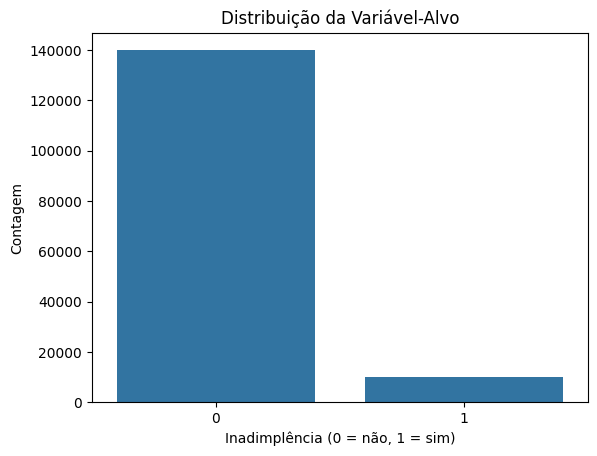

In [29]:
# Visualização rápida do desbalanceamento da variável alvo
sns.countplot(data=df, x='target_default_2y')
plt.title('Distribuição da Variável-Alvo')
plt.xlabel('Inadimplência (0 = não, 1 = sim)')
plt.ylabel('Contagem')
plt.show()


O gráfico reforça visualmente o desbalanceamento da variável-alvo.  
A predominância da classe 0 (não inadimplentes) é evidente, o que confirma a necessidade de estratégias específicas na modelagem para lidar com essa assimetria.  
Essa visualização ajuda a contextualizar o desafio do problema de classificação.

--------

### Distribuições univariadas

#### Análise das variáveis contínuas

Variáveis contínuas do dataset:

- revolving_utilization
- debt_ratio
- monthly_income
- age


In [ ]:
# Função auxiliar para gerar os gráficos de análise para variáveis contínuas

def plot_continuous(df, column):
    """
    Gera visualizações para análise de uma variável contínua.

    A função cria três gráficos lado a lado para a coluna especificada:
    um histograma, um gráfico de densidade (KDE) e um boxplot, auxiliando
    na análise da distribuição dos dados.

    Args:
        df (pandas.DataFrame): DataFrame contendo os dados.
        column (str): Nome da coluna numérica a ser analisada.

    Returns:
        None: A função apenas exibe os gráficos e não retorna valores.

    Raises:
        KeyError: Se a coluna especificada não existir no DataFrame.
        TypeError: Se os dados da coluna não forem compatíveis com as
            funções de plotagem (por exemplo, dados não numéricos).

    Example:
        >>> plot_continuous(df, "age")
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Histograma
    sns.histplot(df[column], kde=False, ax=axes[0])
    axes[0].set_title(f'Histograma - {column}')

    # KDE
    sns.kdeplot(df[column], ax=axes[1])
    axes[1].set_title(f'Distribuição KDE - {column}')

    # Boxplot
    sns.boxplot(x=df[column], ax=axes[2])
    axes[2].set_title(f'Boxplot - {column}')

    plt.tight_layout()
    plt.show()


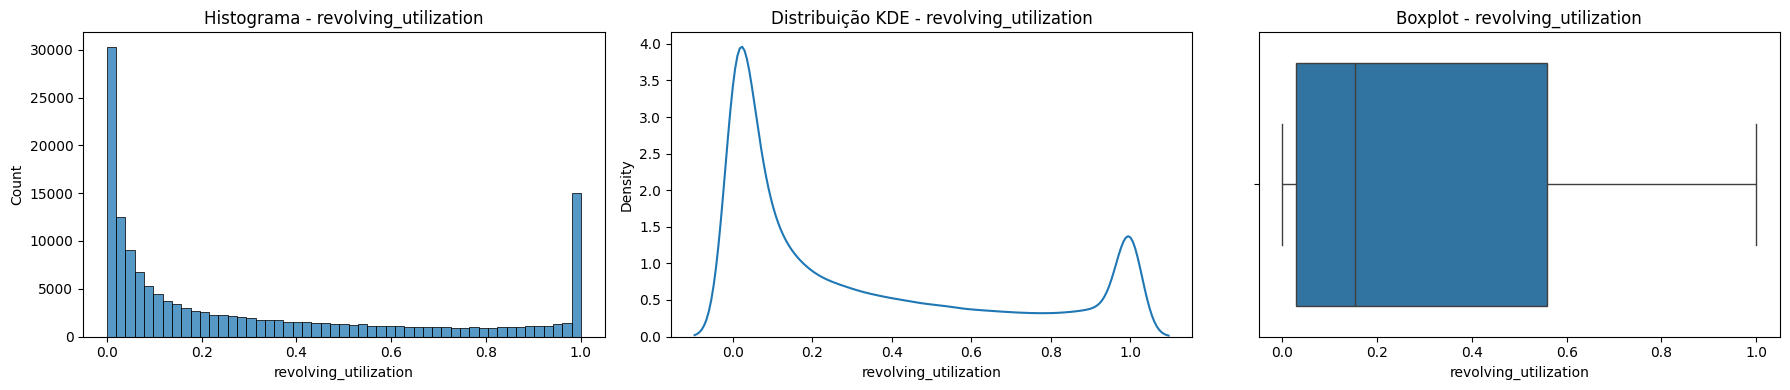

In [34]:
# Análise da variável 'revolving_utilization'
plot_continuous(df, 'revolving_utilization')

A variável apresenta forte assimetria à direita, com grande concentração de valores próximos de 0 e uma cauda longa até valores próximos de 1.

Histograma / KDE: indicam predominância de baixa utilização, mas com um segundo pico próximo de 1, sugerindo um grupo relevante de clientes altamente alavancados.

Boxplot: mediana baixa e alta dispersão, com valores extremos elevados

Como o objetivo é avaliar o risco de crédito, essa variável é potencialmente muito informativa, já que alta utilização tende a estar associada a maior probabilidade de inadimplência.

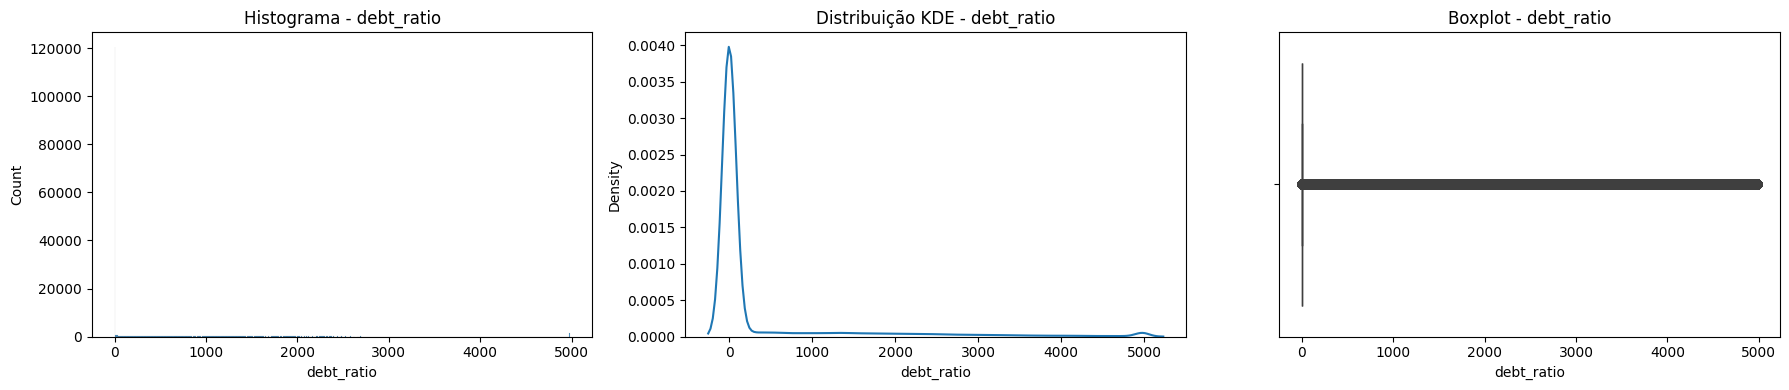

In [35]:
# Análise da variável 'debt_ratio'
plot_continuous(df, 'debt_ratio')

Após aplicação de cap no percentil 99, a variável mantém sua natureza assimétrica à direita, porém com redução do impacto de valores extremos.

Histograma / KDE: a distribuição continua concentrada em valores baixos, mas agora com melhor visualização da massa principal, sem distorção causada por outliers severos.

Boxplot: ainda indica dispersão relevante, porém com redução significativa de extremos inconsistentes.

💡 Interpretação no contexto do problema:
O debt_ratio permanece uma variável importante, pois valores mais altos indicam maior comprometimento da renda. O tratamento preserva casos plausíveis de superendividamento (>1), enquanto remove ruídos extremos.

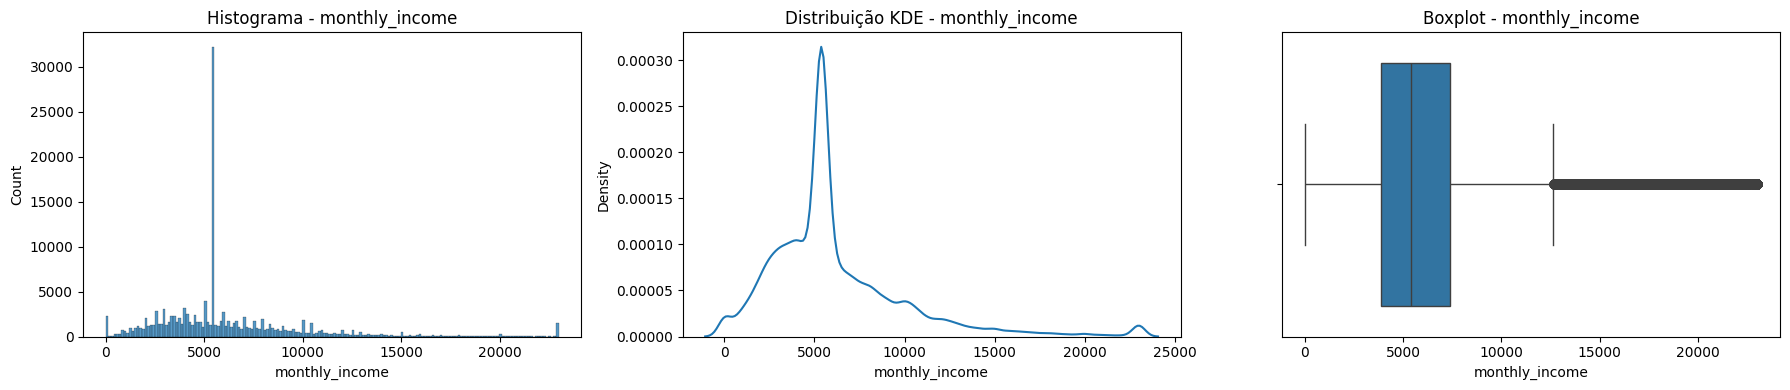

In [42]:
# Análise da variável 'monthly_income'
plot_continuous(df, 'monthly_income')

A variável apresenta assimetria à direita, com concentração de valores em faixas mais baixas e cauda longa para rendas mais altas.

Histograma / KDE: indicam maior densidade entre aproximadamente 2k–7k, com um pico acentuado próximo de 5k e redução gradual à medida que a renda aumenta.

Boxplot: evidencia presença de outliers superiores, representando indivíduos com renda significativamente maior que a média.

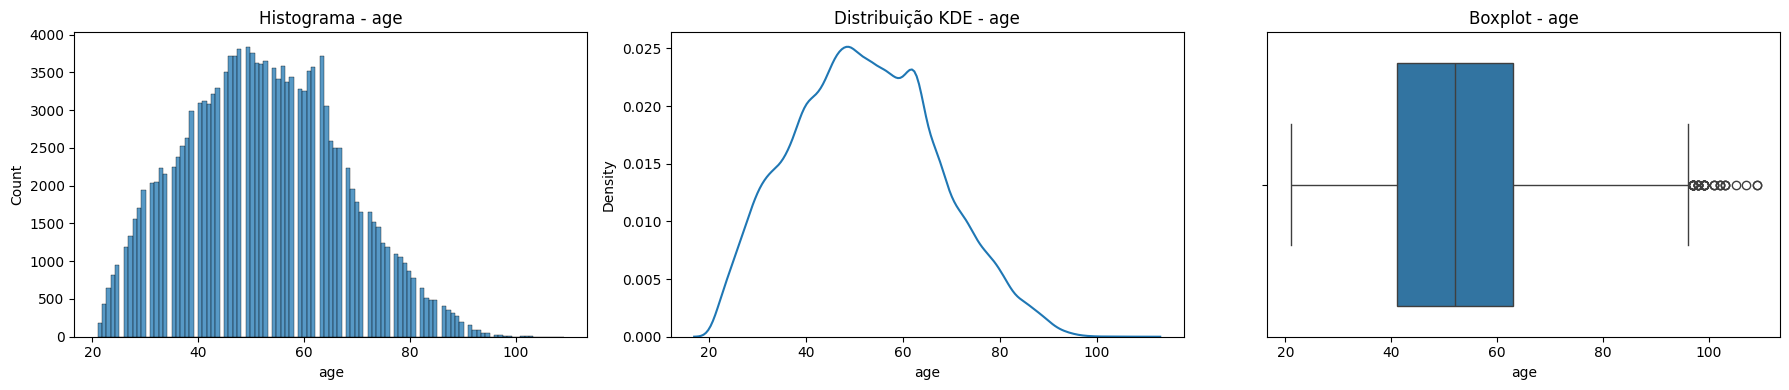

In [43]:
# Análise da variável 'age'
plot_continuous(df, 'age')

A variável apresenta uma distribuição relativamente contínua e levemente assimétrica à direita, com maior concentração entre aproximadamente 40 e 60 anos.

Histograma / KDE: indicam uma distribuição quase unimodal, com pico na meia-idade e queda gradual nas idades mais avançadas.

Boxplot: mostra dispersão moderada e presença de outliers superiores, possivelmente idades muito elevadas.

--------

#### Análise das variáveis discretas

Variáveis discretas:

- num_credit_lines
- num_real_estate_loans
- late_30_59_days
- late_60_89_days
- late_90_plus_days
- num_dependents

In [51]:
def plot_count(df, column):
    """
    Gera a visualização de frequência absoluta para uma coluna específica.

    Cria um gráfico de barras (countplot) para analisar a distribuição de uma
    variável discreta ou categórica. Ao final, imprime o percentual de valores
    iguais a zero na coluna selecionada.

    Args:
        df (pd.DataFrame): O DataFrame contendo os dados.
        column (str): O nome da coluna a ser visualizada. Deve conter dados numéricos
            ou categóricos compatíveis com as funções de plotagem.

    Returns:
        None: A função exibe o gráfico diretamente e imprime estatísticas no console.

    Raises:
        KeyError: Se a coluna informada não existir no DataFrame.
    """
    plt.figure(figsize=(8, 4))

    # Barplot de frequências
    sns.countplot(x=df[column])
    plt.title(f'Frequência Absoluta - {column}')
    plt.xlabel(column)
    plt.ylabel('Contagem')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # Contagem de zeros
    zeros = (df[column] == 0).mean() * 100
    print(f"Percentual de zeros em {column}: {zeros:.2f}%")

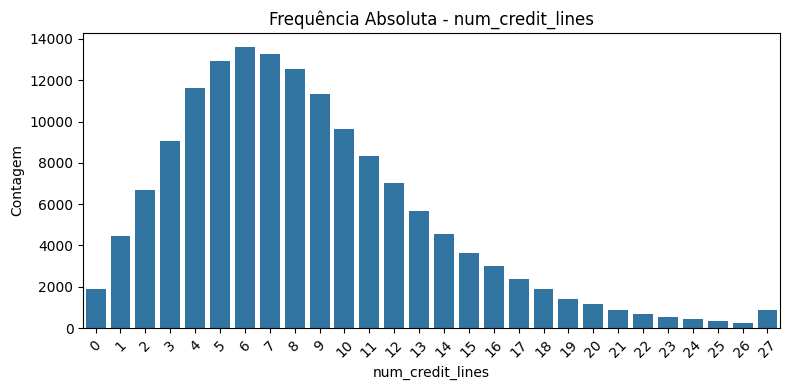

Percentual de zeros em num_credit_lines: 1.26%


In [52]:
plot_count(df, 'num_credit_lines')

O gráfico mostra a distribuição da variável `num_credit_lines`, revelando um padrão típico de variáveis de crédito: a maior parte dos clientes possui entre 4 e 10 linhas de crédito, com um pico claro em torno de 6 a 7 linhas. A distribuição é assimétrica à direita, indicando que valores mais altos existem, mas são progressivamente menos frequentes. Esse comportamento sugere que a maioria dos indivíduos mantém um número moderado de contas ativas, enquanto apenas uma pequena parcela possui muitas linhas de crédito. Essa informação é útil para entender o perfil financeiro geral da base e pode influenciar a interpretação de risco nas etapas seguintes.

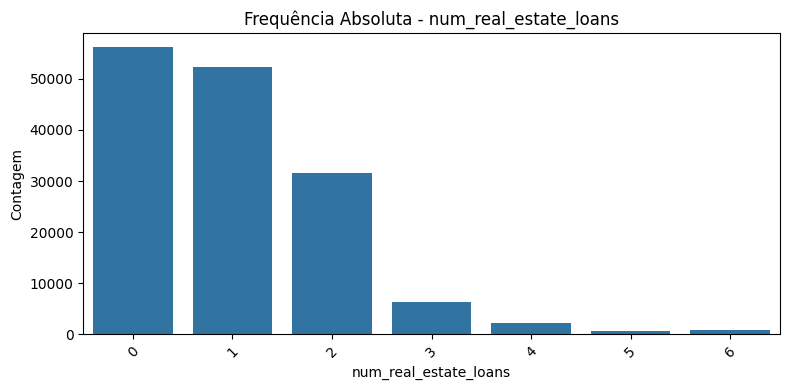

Percentual de zeros em num_real_estate_loans: 37.46%


In [53]:
plot_count(df, 'num_real_estate_loans')

A distribuição de `num_real_estate_loans` mostra um comportamento bastante concentrado: a grande maioria dos clientes possui **0 ou 1 empréstimo imobiliário**, com a frequência caindo rapidamente conforme o número de empréstimos aumenta. Esse padrão é esperado, já que imóveis são bens de alto valor e a maior parte das pessoas mantém apenas um financiamento ativo ao longo da vida. A cauda direita curta indica que poucos indivíduos possuem múltiplos empréstimos imobiliários, o que pode representar um perfil financeiro mais robusto ou, em alguns casos, maior exposição ao risco. Essa variável tende a ser informativa para o modelo, especialmente na diferenciação entre perfis mais conservadores e perfis com maior alavancagem patrimonial.

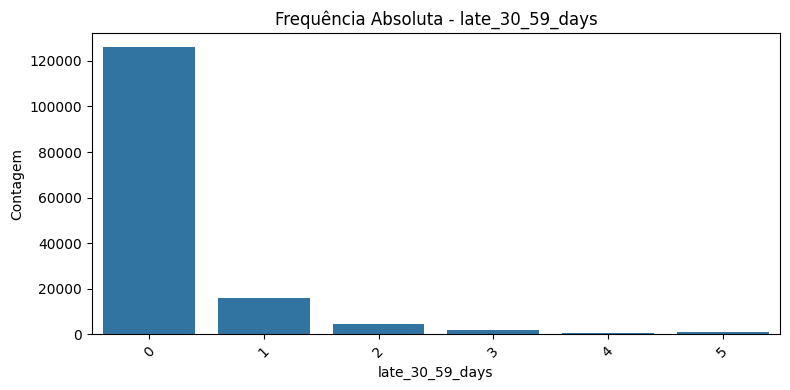

Percentual de zeros em late_30_59_days: 84.01%


In [54]:
plot_count(df, 'late_30_59_days')

A variável `late_30_59_days` apresenta uma distribuição extremamente concentrada em zero, indicando que a grande maioria dos clientes **nunca atrasou pagamentos entre 30 e 59 dias**. À medida que o número de ocorrências aumenta, a frequência cai rapidamente, o que é esperado para esse tipo de variável comportamental. A presença de poucos clientes com múltiplos atrasos nessa faixa já sinaliza um comportamento de risco mais elevado, pois atrasos recorrentes são fortes indicadores de inadimplência futura. Essa assimetria acentuada reforça a importância dessa variável na modelagem, mesmo sendo altamente esparsa.

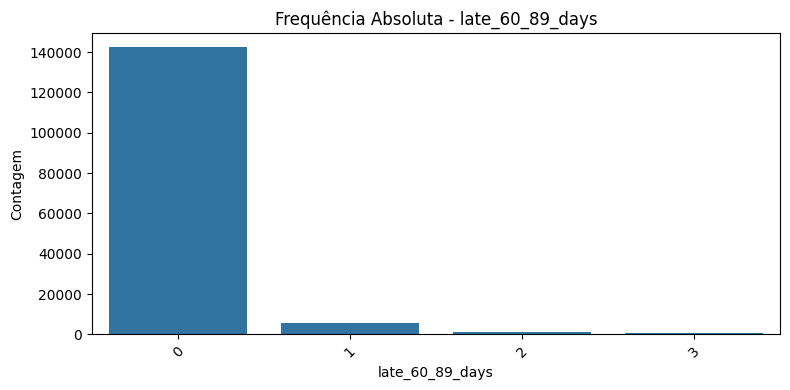

Percentual de zeros em late_60_89_days: 94.93%


In [55]:
plot_count(df, 'late_60_89_days')

A variável `late_60_89_days` apresenta uma concentração ainda mais extrema em zero, com mais de 94% dos clientes sem qualquer atraso entre 60 e 89 dias. Esse comportamento é esperado, pois atrasos nessa faixa já representam um nível elevado de risco e tendem a ocorrer apenas em uma minoria da base. A queda acentuada na frequência conforme o número de ocorrências aumenta reforça o caráter altamente esparso da variável. Mesmo assim, a presença de valores diferentes de zero é extremamente relevante, já que atrasos prolongados são fortes preditores de inadimplência futura e podem exercer grande influência na modelagem.

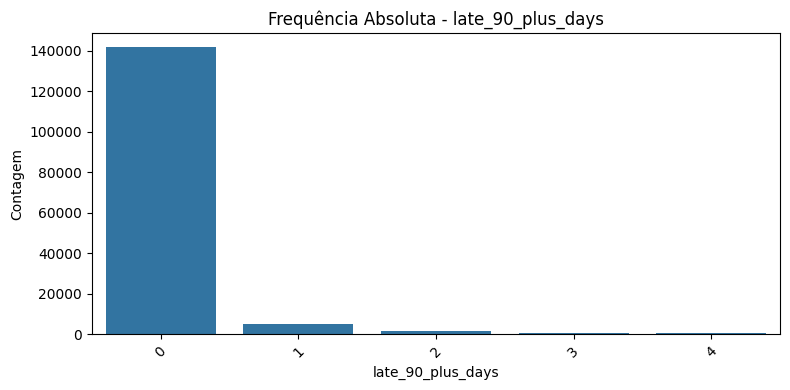

Percentual de zeros em late_90_plus_days: 94.44%


In [56]:
plot_count(df, 'late_90_plus_days')

A variável `late_90_plus_days` apresenta a concentração mais extrema entre todas as variáveis de atraso: a imensa maioria dos clientes nunca registrou atrasos superiores a 90 dias, enquanto apenas uma pequena fração possui uma ou mais ocorrências. Esse padrão é esperado, já que atrasos acima de 90 dias representam um nível severo de inadimplência e tendem a ocorrer apenas em casos de risco muito elevado. Apesar de rara, a presença de valores diferentes de zero é altamente informativa, pois indica um comportamento financeiro crítico e fortemente associado à probabilidade de default futuro. Essa variável, mesmo esparsa, costuma ter grande poder preditivo em modelos de risco de crédito.

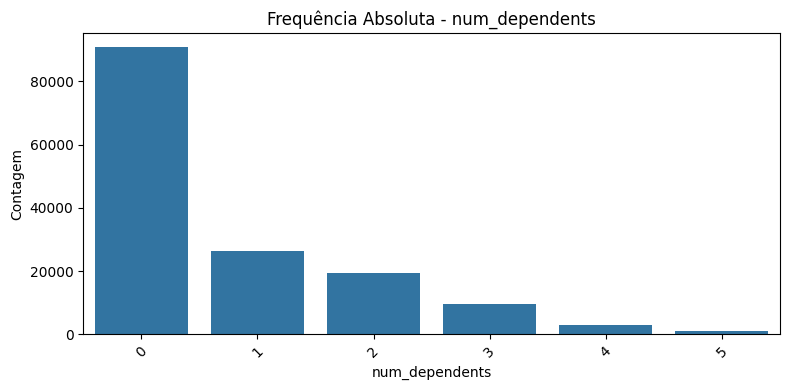

Percentual de zeros em num_dependents: 60.55%


In [57]:
plot_count(df, 'num_dependents')

A variável `num_dependents` apresenta uma distribuição concentrada nos valores mais baixos, com destaque para o fato de que cerca de 60% dos clientes não possuem dependentes. A frequência diminui gradualmente conforme o número de dependentes aumenta, o que é consistente com padrões demográficos típicos. Essa variável pode influenciar a capacidade financeira do cliente, já que um maior número de dependentes tende a aumentar despesas fixas e reduzir a folga orçamentária. Embora não seja tão esparsa quanto as variáveis de atraso, sua assimetria e concentração em valores baixos são características importantes a serem consideradas na modelagem.

### Análise da variável alvo

### Relações Bivariadas com a Variável-Alvo

### Correlações e Interações

### Conclusões